In [37]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

In [39]:
df = pd.read_csv(r'C:\Users\Admin\Downloads\week3_DiyaGarg\Country-data.csv')
print(f'Shape: {df.shape[0]} countries × {df.shape[1]} features')
print(f'Columns: {list(df.columns)}')

Shape: 167 countries × 10 features
Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [40]:
df.head(10)
df.info()
df.describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 14.5 KB


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


In [41]:
print('Missing Values')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')

Missing Values
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Total missing values: 0
Duplicate rows: 0


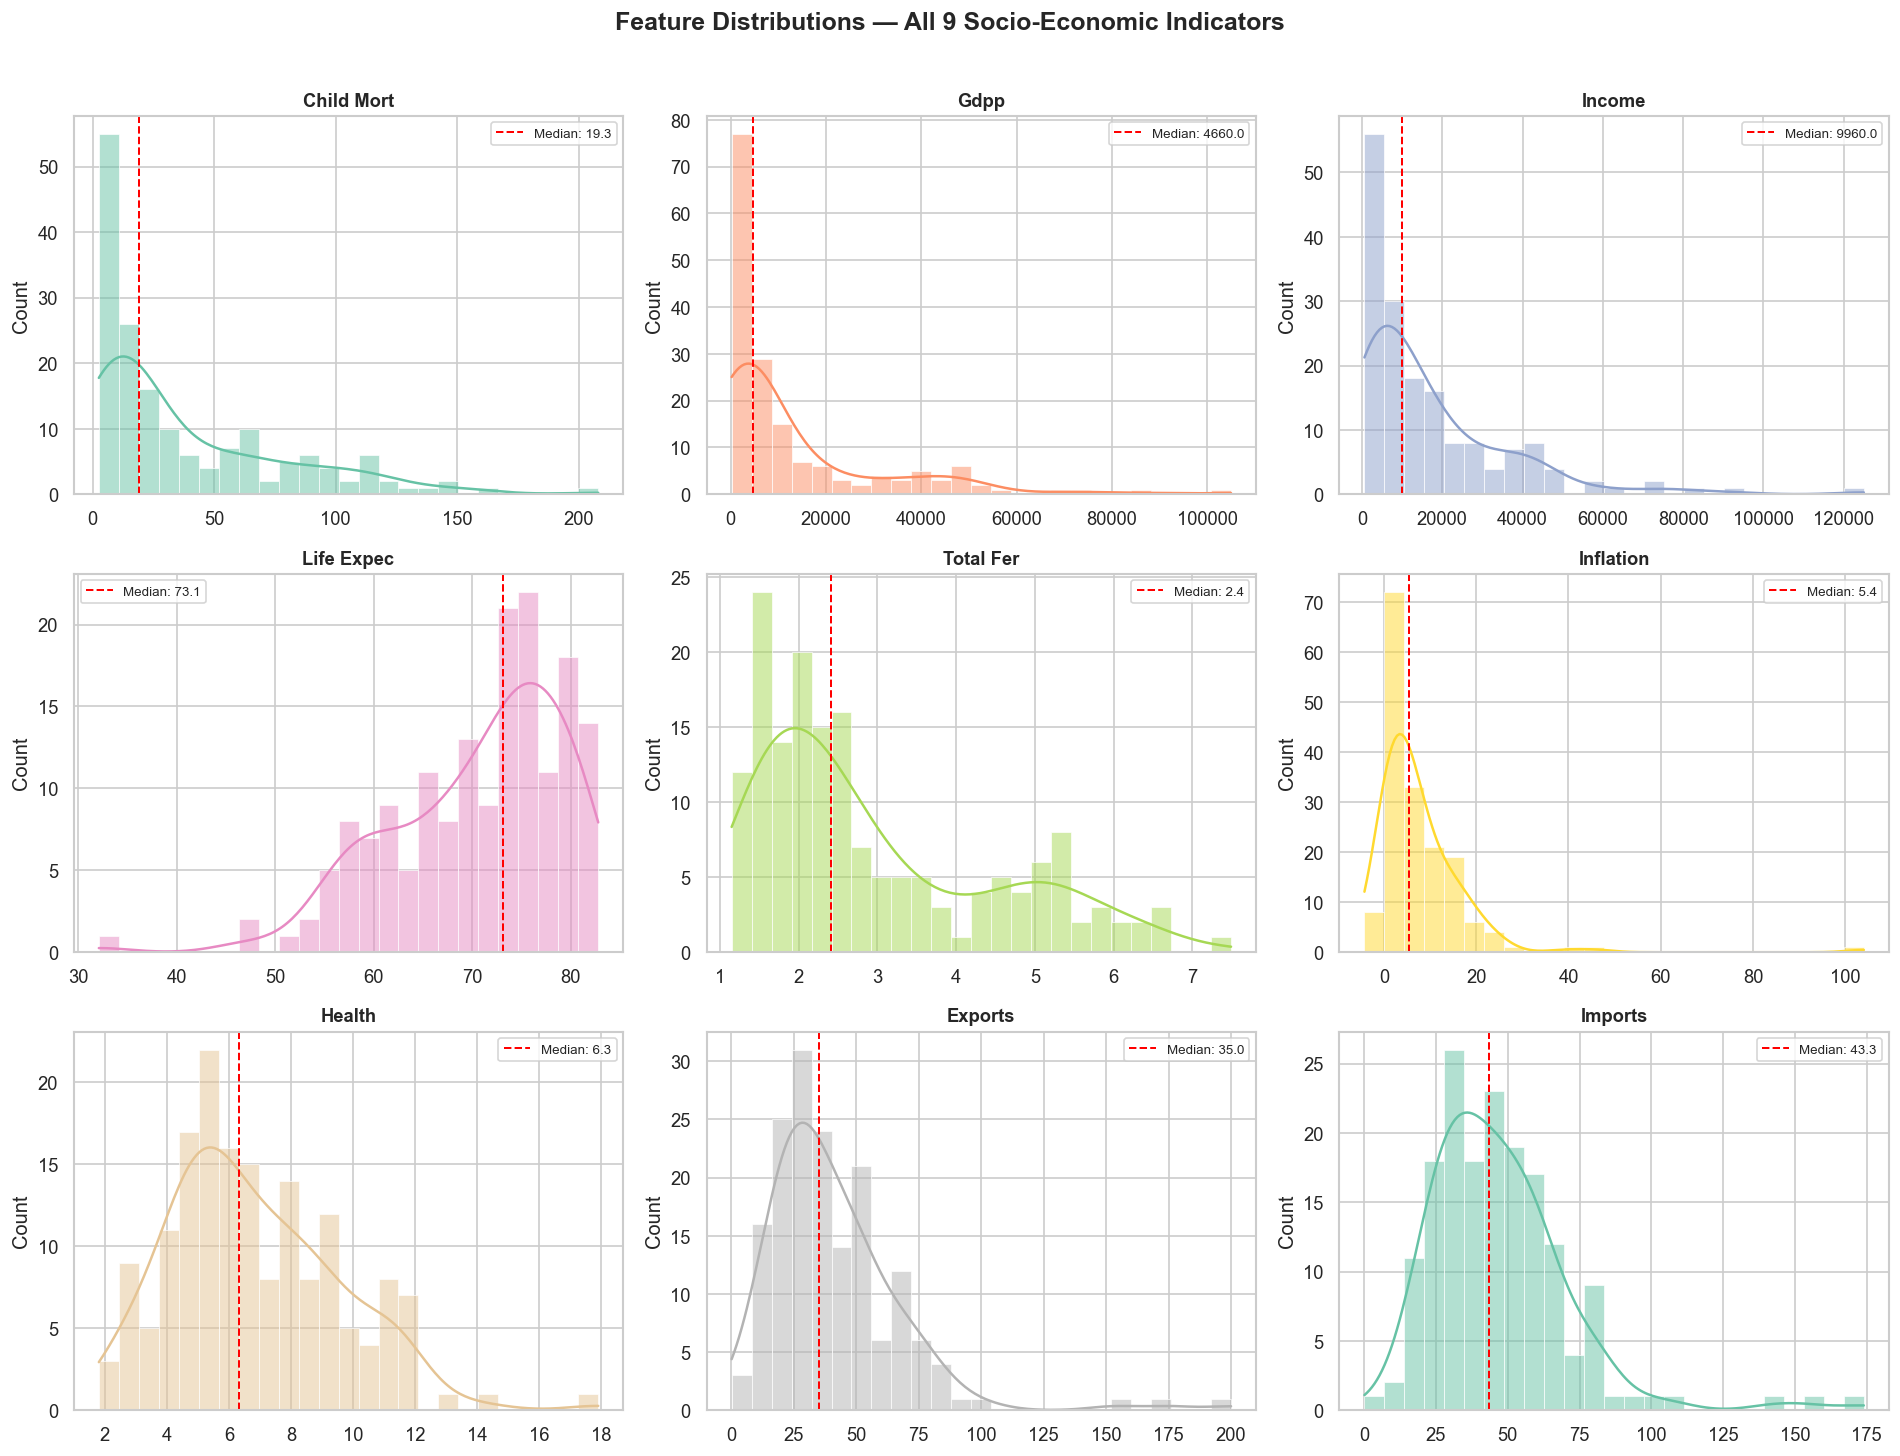

In [42]:
features = ['child_mort', 'gdpp', 'income', 'life_expec','total_fer', 'inflation', 'health', 'exports', 'imports']
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Feature Distributions — All 9 Socio-Economic Indicators',fontsize=15, fontweight='bold', y=1.01)
colors = sns.color_palette('Set2', 9)

for feat, ax, color in zip(features, axes.flatten(), colors):
    sns.histplot(df[feat], kde=True, ax=ax, color=color,bins=25, edgecolor='white', linewidth=0.4)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.axvline(df[feat].median(), color='red', linestyle='--',linewidth=1.2, label=f'Median: {df[feat].median():.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

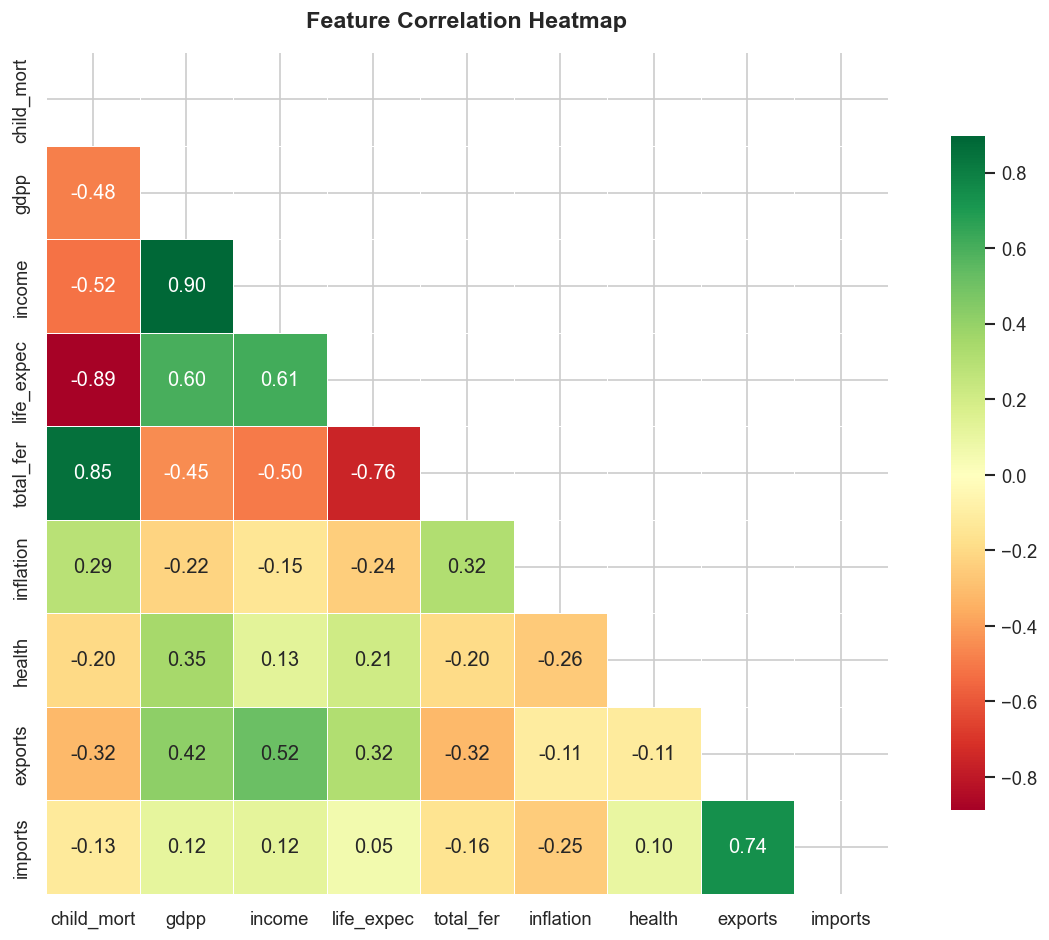

In [43]:
fig, ax = plt.subplots(figsize=(11, 8))
corr_matrix = df[features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,mask=mask,annot=True,fmt='.2f',cmap='RdYlGn',center=0,linewidths=0.5,ax=ax,square=True, cbar_kws={'shrink': 0.8}
)

ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

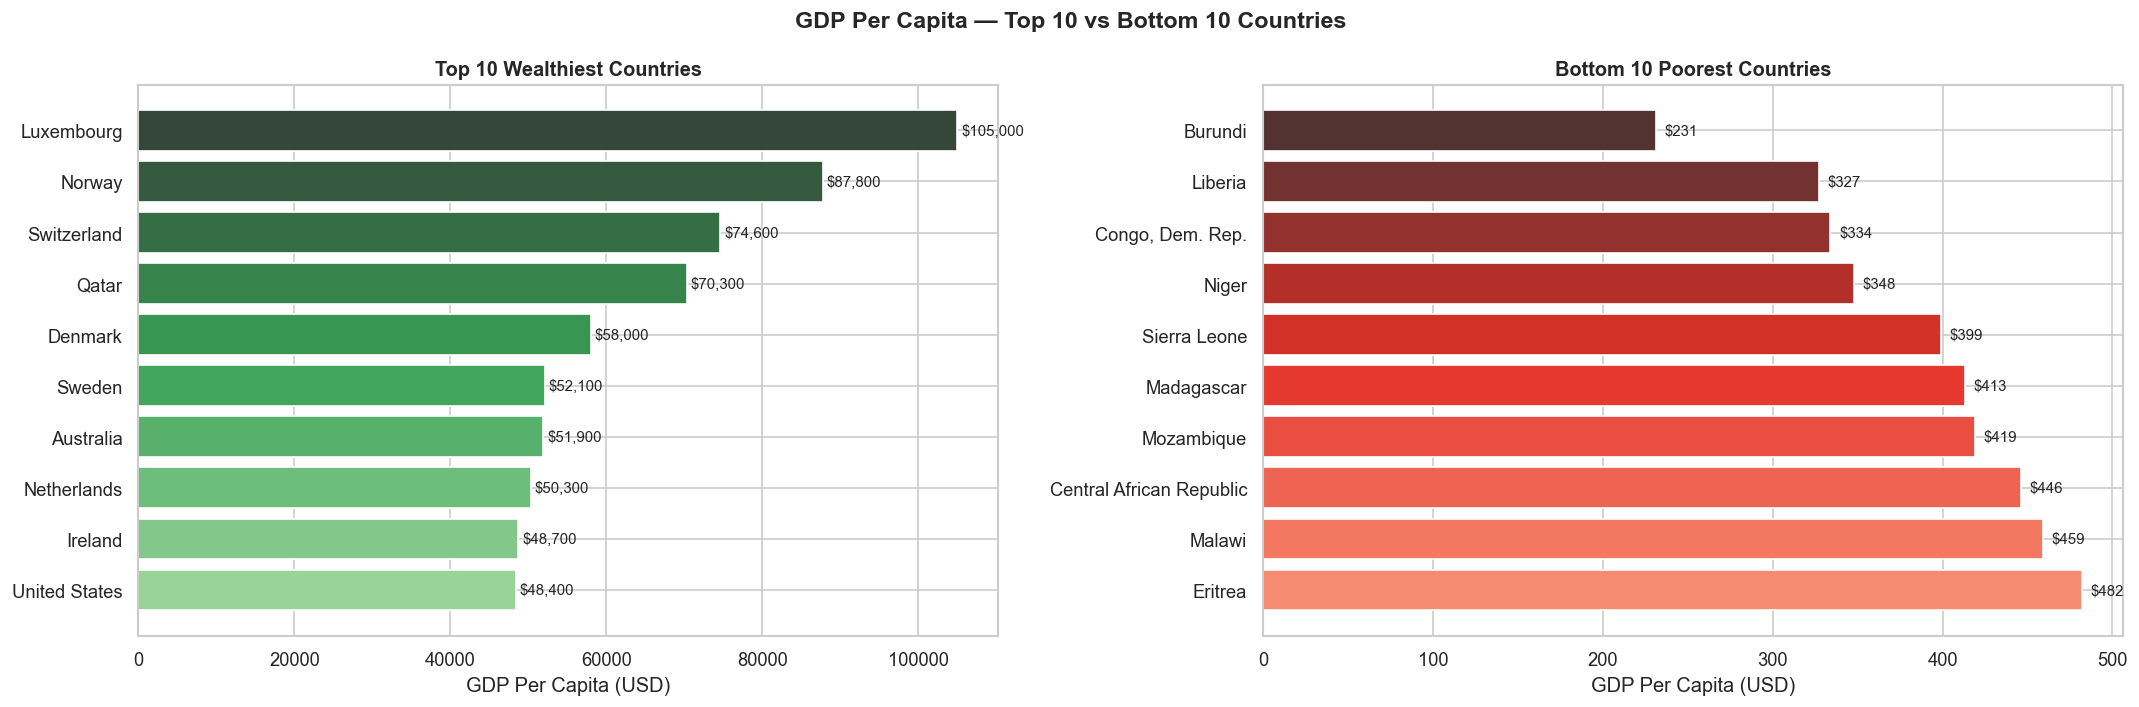

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('GDP Per Capita — Top 10 vs Bottom 10 Countries',fontsize=14, fontweight='bold')

top10 = df.nlargest(10, 'gdpp')[['country', 'gdpp']].sort_values('gdpp')
axes[0].barh(top10['country'], top10['gdpp'], 
             color=sns.color_palette('Greens_d', 10))
axes[0].set_title('Top 10 Wealthiest Countries', fontsize=12, fontweight='bold')
axes[0].set_xlabel('GDP Per Capita (USD)')
for i, val in enumerate(top10['gdpp']):
    axes[0].text(val + 500, i, f'${val:,}', va='center', fontsize=9)

bot10 = df.nsmallest(10, 'gdpp')[['country', 'gdpp']].sort_values('gdpp', ascending=False)
axes[1].barh(bot10['country'], bot10['gdpp'], 
             color=sns.color_palette('Reds_d', 10))
axes[1].set_title('Bottom 10 Poorest Countries', fontsize=12, fontweight='bold')
axes[1].set_xlabel('GDP Per Capita (USD)')
for i, val in enumerate(bot10['gdpp']):
    axes[1].text(val + 5, i, f'${val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

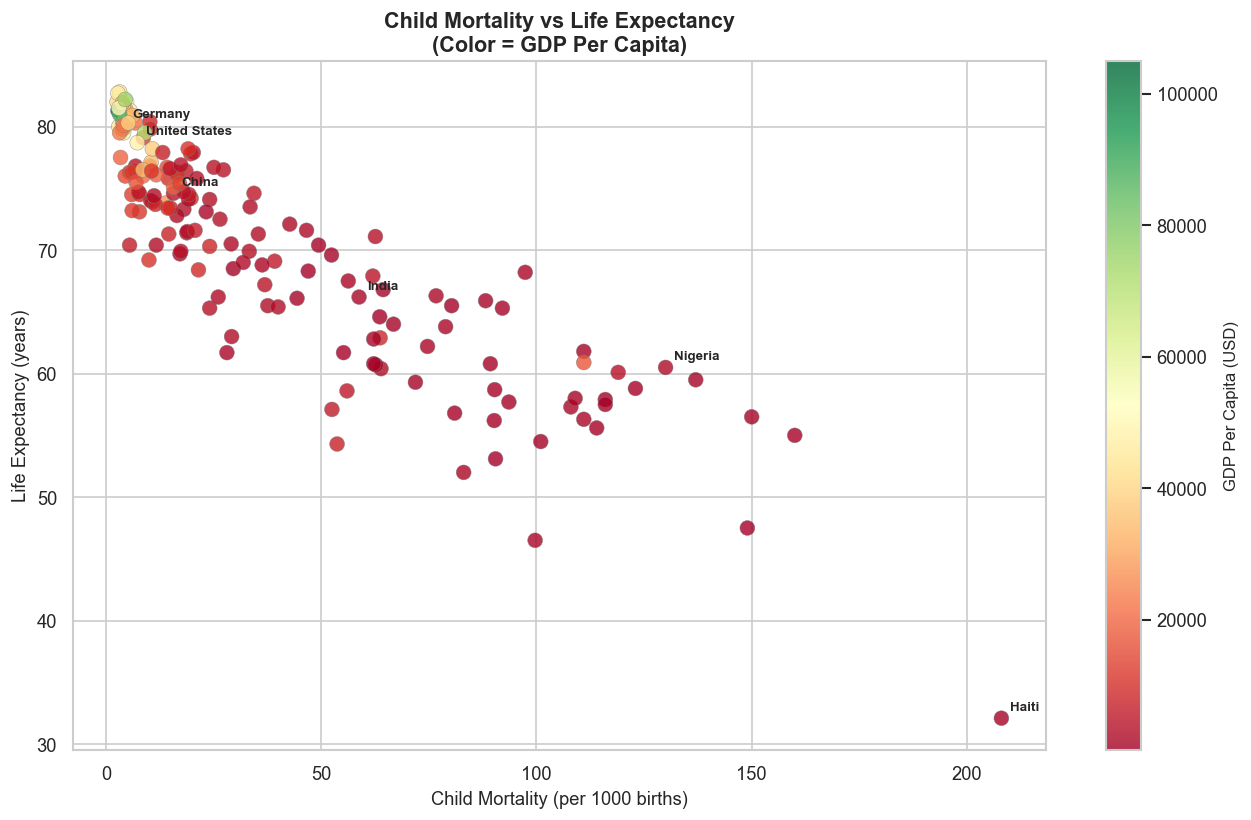

In [45]:
fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(df['child_mort'],df['life_expec'],c=df['gdpp'],cmap='RdYlGn',s=80,alpha=0.8,edgecolors='grey',linewidth=0.3
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('GDP Per Capita (USD)', fontsize=10)

notable = ['United States', 'India', 'Nigeria', 'Germany', 'Haiti', 'China']
for _, row in df[df['country'].isin(notable)].iterrows():
    ax.annotate(row['country'], 
                (row['child_mort'], row['life_expec']),
                fontsize=8, xytext=(5, 5), 
                textcoords='offset points',
                fontweight='bold')

ax.set_xlabel('Child Mortality (per 1000 births)', fontsize=11)
ax.set_ylabel('Life Expectancy (years)', fontsize=11)
ax.set_title('Child Mortality vs Life Expectancy\n(Color = GDP Per Capita)', 
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [46]:
df.columns = df.columns.str.strip()
print(' Column whitespace stripped')
print(f'   Columns : {list(df.columns)}')

df = df.drop_duplicates()
print(f'\n Duplicates dropped')
print(f'   Shape after : {df.shape}')

features = ['child_mort', 'exports', 'health', 'imports', 
            'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
for col in features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print(f'\n Numeric types enforced')

for col in features:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
print(f'\n Median imputation applied')
print(f'   Missing values remaining : {df.isnull().sum().sum()}')


 Column whitespace stripped
   Columns : ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

 Duplicates dropped
   Shape after : (167, 10)

 Numeric types enforced

 Median imputation applied
   Missing values remaining : 0


In [47]:
X = df.drop('country', axis=1)
print(f'Feature matrix shape : {X.shape}')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'   Mean of scaled data  : {X_scaled.mean().round(4)}  (should be ~0)')
print(f'   Std of scaled data   : {X_scaled.std().round(4)}   (should be ~1)')

Feature matrix shape : (167, 9)
   Mean of scaled data  : 0.0  (should be ~0)
   Std of scaled data   : 1.0   (should be ~1)


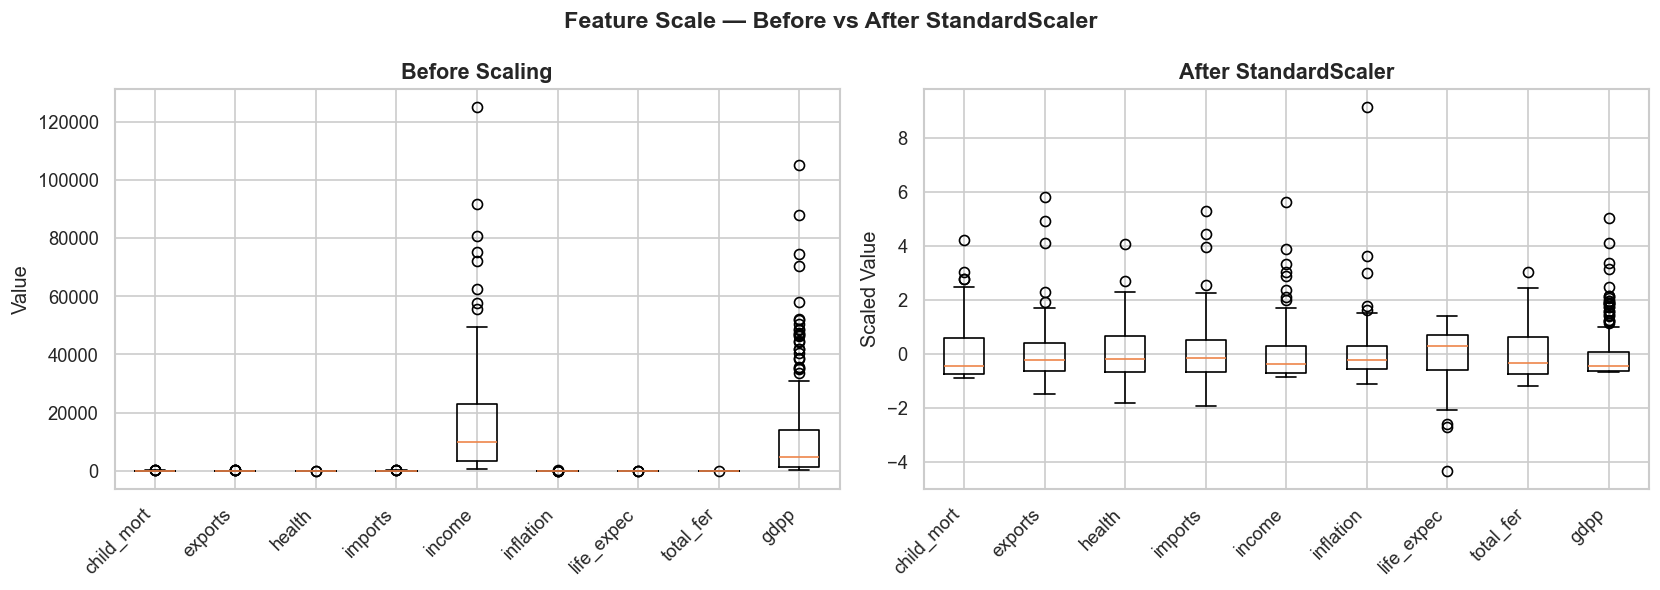

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
axes[0].boxplot(X.values, labels=X.columns, vert=True)
axes[0].set_title('Before Scaling', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(X.columns, rotation=45, ha='right')
axes[0].set_ylabel('Value')

# After scaling
axes[1].boxplot(X_scaled, labels=X.columns, vert=True)
axes[1].set_title('After StandardScaler', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(X.columns, rotation=45, ha='right')
axes[1].set_ylabel('Scaled Value')

fig.suptitle('Feature Scale — Before vs After StandardScaler', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [49]:
inertia_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
    print(f'k={k}  →  inertia: {kmeans.inertia_:.2f}')


k=2  →  inertia: 1050.21
k=3  →  inertia: 831.42
k=4  →  inertia: 700.52
k=5  →  inertia: 620.16
k=6  →  inertia: 558.47
k=7  →  inertia: 495.81
k=8  →  inertia: 457.59
k=9  →  inertia: 427.80
k=10  →  inertia: 403.23


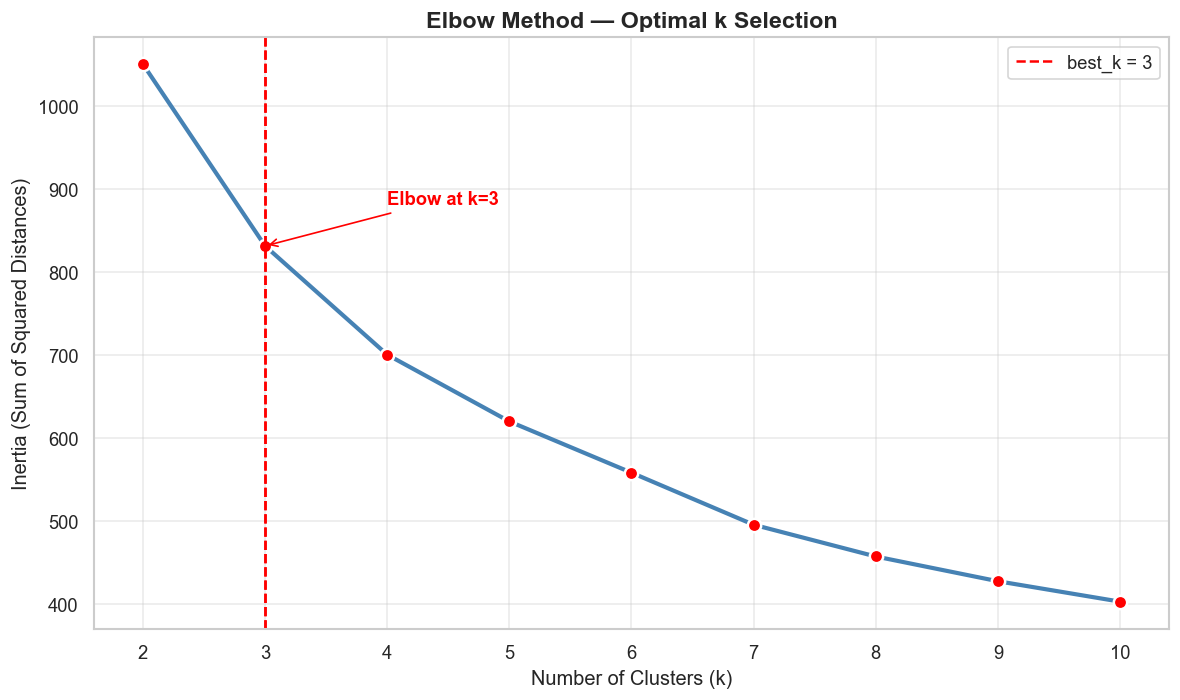

In [50]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(k_range, inertia_values,marker='o',markersize=8,linewidth=2.5,color='steelblue',markerfacecolor='red',markeredgecolor='white',markeredgewidth=1.5)
ax.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='best_k = 3')
ax.axvline(x=3, color='red', linestyle='--', linewidth=1.5)
ax.annotate('Elbow at k=3', 
            xy=(3, inertia_values[1]),
            xytext=(4, inertia_values[1] + 50),
            fontsize=11,
            color='red',
            fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia (Sum of Squared Distances)', fontsize=12)
ax.set_title('Elbow Method — Optimal k Selection', fontsize=14, fontweight='bold')
ax.set_xticks(list(k_range))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

In [51]:
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)
df['Cluster'] = kmeans.labels_

print(f'   Number of clusters : {best_k}')
print(f'\n── Countries per Cluster ──')
print(df['Cluster'].value_counts().sort_index())

   Number of clusters : 3

── Countries per Cluster ──
Cluster
0    36
1    47
2    84
Name: count, dtype: int64


In [53]:
sil_score = silhouette_score(X_scaled, kmeans.labels_)
print('Silhouette Score — K-Means')
print(f'\n   Score : {sil_score:.4f}')

if sil_score > 0.5:
    print('   Result :Strong cluster separation')
elif sil_score > 0.3:
    print('   Result :Moderate cluster separation — acceptable')
else:
    print('   Result :Weak separation — consider tuning')

print(f'\n   Interpretation:')
print(f' Score close to +1 = clusters are dense and well separated')
print(f'Score close to  0 = clusters are overlapping')
print(f'Score close to -1 = points assigned to wrong clusters')

Silhouette Score — K-Means

   Score : 0.2833
   Result :Weak separation — consider tuning

   Interpretation:
 Score close to +1 = clusters are dense and well separated
Score close to  0 = clusters are overlapping
Score close to -1 = points assigned to wrong clusters


In [54]:
cluster_profile = df.groupby('Cluster')[features].mean().round(2)
cluster_profile['Country Count'] = df['Cluster'].value_counts().sort_index()
cluster_names = {0: 'Underdeveloped',1: 'Developing',2: 'Developed'}
cluster_profile.index = [cluster_names[i] for i in cluster_profile.index]

print('── Cluster Profile Table ──\n')
print(cluster_profile.to_string())

── Cluster Profile Table ──

                child_mort  exports  health  imports    income  inflation  life_expec  total_fer      gdpp  Country Count
Underdeveloped        5.00    58.74    8.81    51.49  45672.22       2.67       80.13       1.75  42494.44             36
Developing           92.96    29.15    6.39    42.32   3942.40      12.02       59.19       5.01   1922.38             47
Developed            21.93    40.24    6.20    47.47  12305.60       7.60       72.81       2.31   6486.45             84


In [55]:
print('Country Spotlight per Cluster\n')

for cluster_id, name in cluster_names.items():
    countries = df[df['Cluster'] == cluster_id]['country'].values
    print(f'{name}')
    print(f'Total countries : {len(countries)}')
    print(f'Sample countries: {", ".join(countries[:8])}')
    print()

Country Spotlight per Cluster

Underdeveloped
Total countries : 36
Sample countries: Australia, Austria, Bahrain, Belgium, Brunei, Canada, Cyprus, Czech Republic

Developing
Total countries : 47
Sample countries: Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic

Developed
Total countries : 84
Sample countries: Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahamas, Bangladesh



In [56]:
# Train DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = dbscan_labels

unique_labels = set(dbscan_labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f'\nDBSCAN Results ')
print(f'Clusters found: {n_clusters}')
print(f'Noise points : {n_noise} countries marked as outliers')
print(f'\n Noise Countries (Outliers)')
noise_countries = df[df['DBSCAN_Cluster'] == -1]['country'].values
print(f' {", ".join(noise_countries)}')

print(f'\n Countries per DBSCAN Cluster')
print(df['DBSCAN_Cluster'].value_counts().sort_index())


DBSCAN Results 
Clusters found: 1
Noise points : 30 countries marked as outliers

 Noise Countries (Outliers)
 Angola, Brunei, Central African Republic, Congo, Dem. Rep., Congo, Rep., Equatorial Guinea, Gabon, Haiti, Iraq, Ireland, Kiribati, Kuwait, Lesotho, Liberia, Luxembourg, Malta, Micronesia, Fed. Sts., Mongolia, Nigeria, Norway, Qatar, Rwanda, Seychelles, Sierra Leone, Singapore, South Africa, Timor-Leste, Turkmenistan, United States, Venezuela

 Countries per DBSCAN Cluster
DBSCAN_Cluster
-1     30
 0    137
Name: count, dtype: int64


In [57]:
print('── K-Means vs DBSCAN Comparison ──\n')
print(f' {"Metric":<30} {"K-Means":>12} {"DBSCAN":>12}')
print(f' {"─"*54}')
print(f'{"Number of Clusters":<30} {"3":>12} {str(n_clusters):>12}')
print(f'{"Noise Points":<30} {"0":>12} {str(n_noise):>12}')
print(f'{"Requires k upfront":<30} {"Yes":>12} {"No":>12}')
print(f'{"Handles Outliers":<30} {"No":>12} {"Yes":>12}')
print(f'{"Cluster Shape":<30} {"Spherical":>12} {"Any Shape":>12}')

# Silhouette for DBSCAN (only on non-noise points)
non_noise_mask = dbscan_labels != -1
if non_noise_mask.sum() > 1 and len(set(dbscan_labels[non_noise_mask])) > 1:
    dbscan_sil = silhouette_score(X_scaled[non_noise_mask],dbscan_labels[non_noise_mask])
    print(f' {"Silhouette Score":<30} {sil_score:>12.4f} {dbscan_sil:>12.4f}')

── K-Means vs DBSCAN Comparison ──

 Metric                              K-Means       DBSCAN
 ──────────────────────────────────────────────────────
Number of Clusters                        3            1
Noise Points                              0           30
Requires k upfront                      Yes           No
Handles Outliers                         No          Yes
Cluster Shape                     Spherical    Any Shape


In [58]:
# Reduce to 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f'PC1 : {explained[0]*100:.1f}%')
print(f' PC2 : {explained[1]*100:.1f}%')
print(f'Total explained : {sum(explained)*100:.1f}%')

PC1 : 46.0%
 PC2 : 17.2%
Total explained : 63.1%


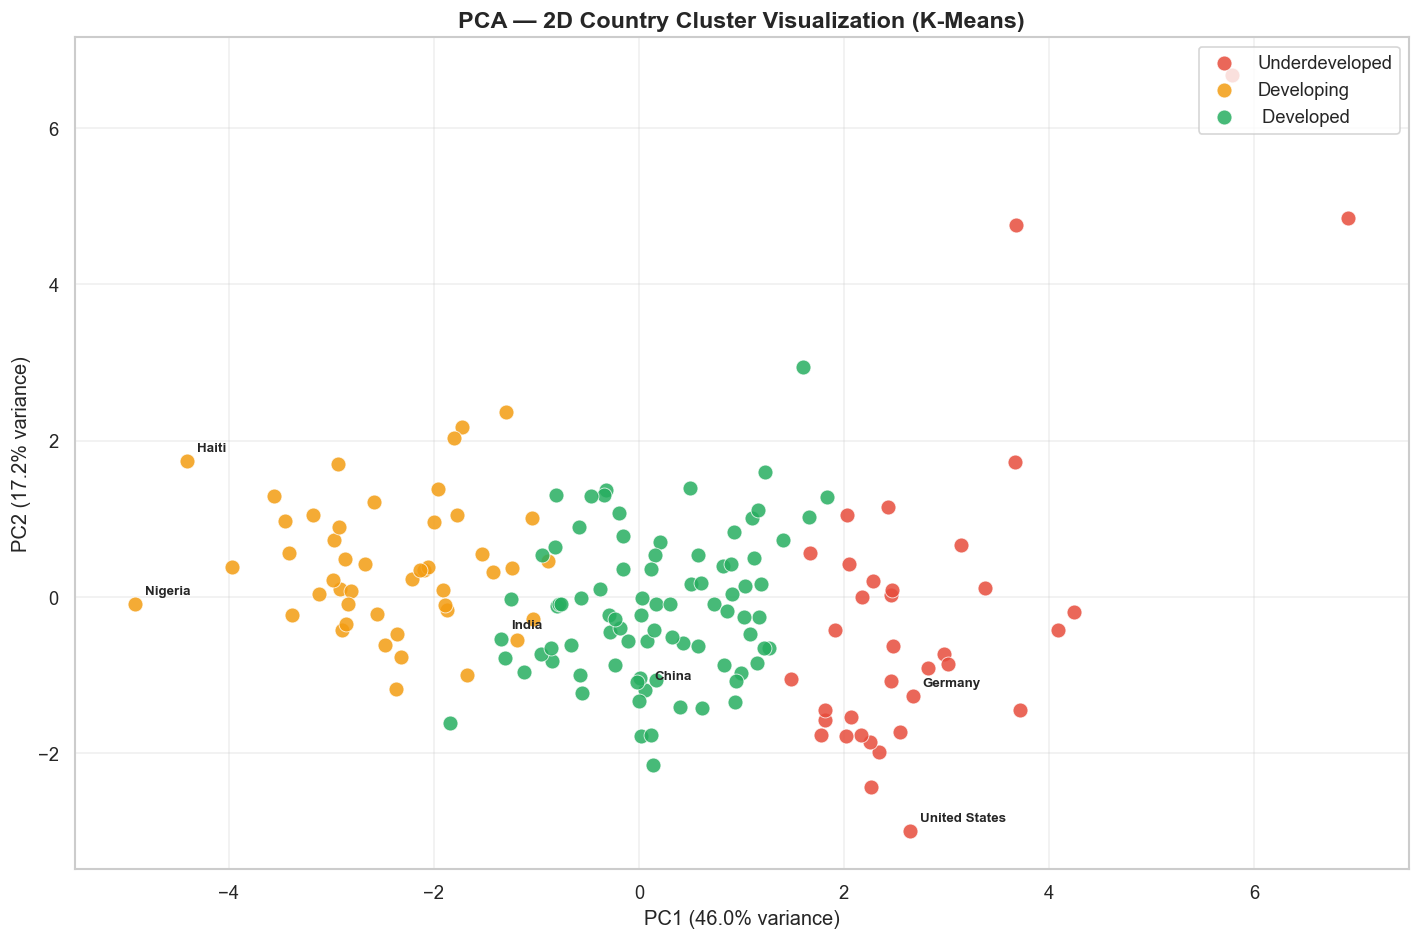

In [59]:
colors = ['#e74c3c', '#f39c12', '#27ae60']
labels_map = {0: 'Underdeveloped', 1: 'Developing', 2: ' Developed'}

fig, ax = plt.subplots(figsize=(12, 8))
for cluster_id in range(3):
    mask = kmeans.labels_ == cluster_id
    ax.scatter(X_pca[mask, 0],  X_pca[mask, 1], c=colors[cluster_id],label=labels_map[cluster_id],s=80,alpha=0.85,edgecolors='white',linewidth=0.5
    )

notable = ['United States', 'Germany', 'India', 'China', 'Nigeria', 'Haiti']
for _, row in df[df['country'].isin(notable)].iterrows():
    idx = df.index.get_loc(_)
    ax.annotate(row['country'],
                (X_pca[idx, 0], X_pca[idx, 1]),
                fontsize=8,
                fontweight='bold',
                xytext=(6, 6),
                textcoords='offset points')

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA — 2D Country Cluster Visualization (K-Means)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

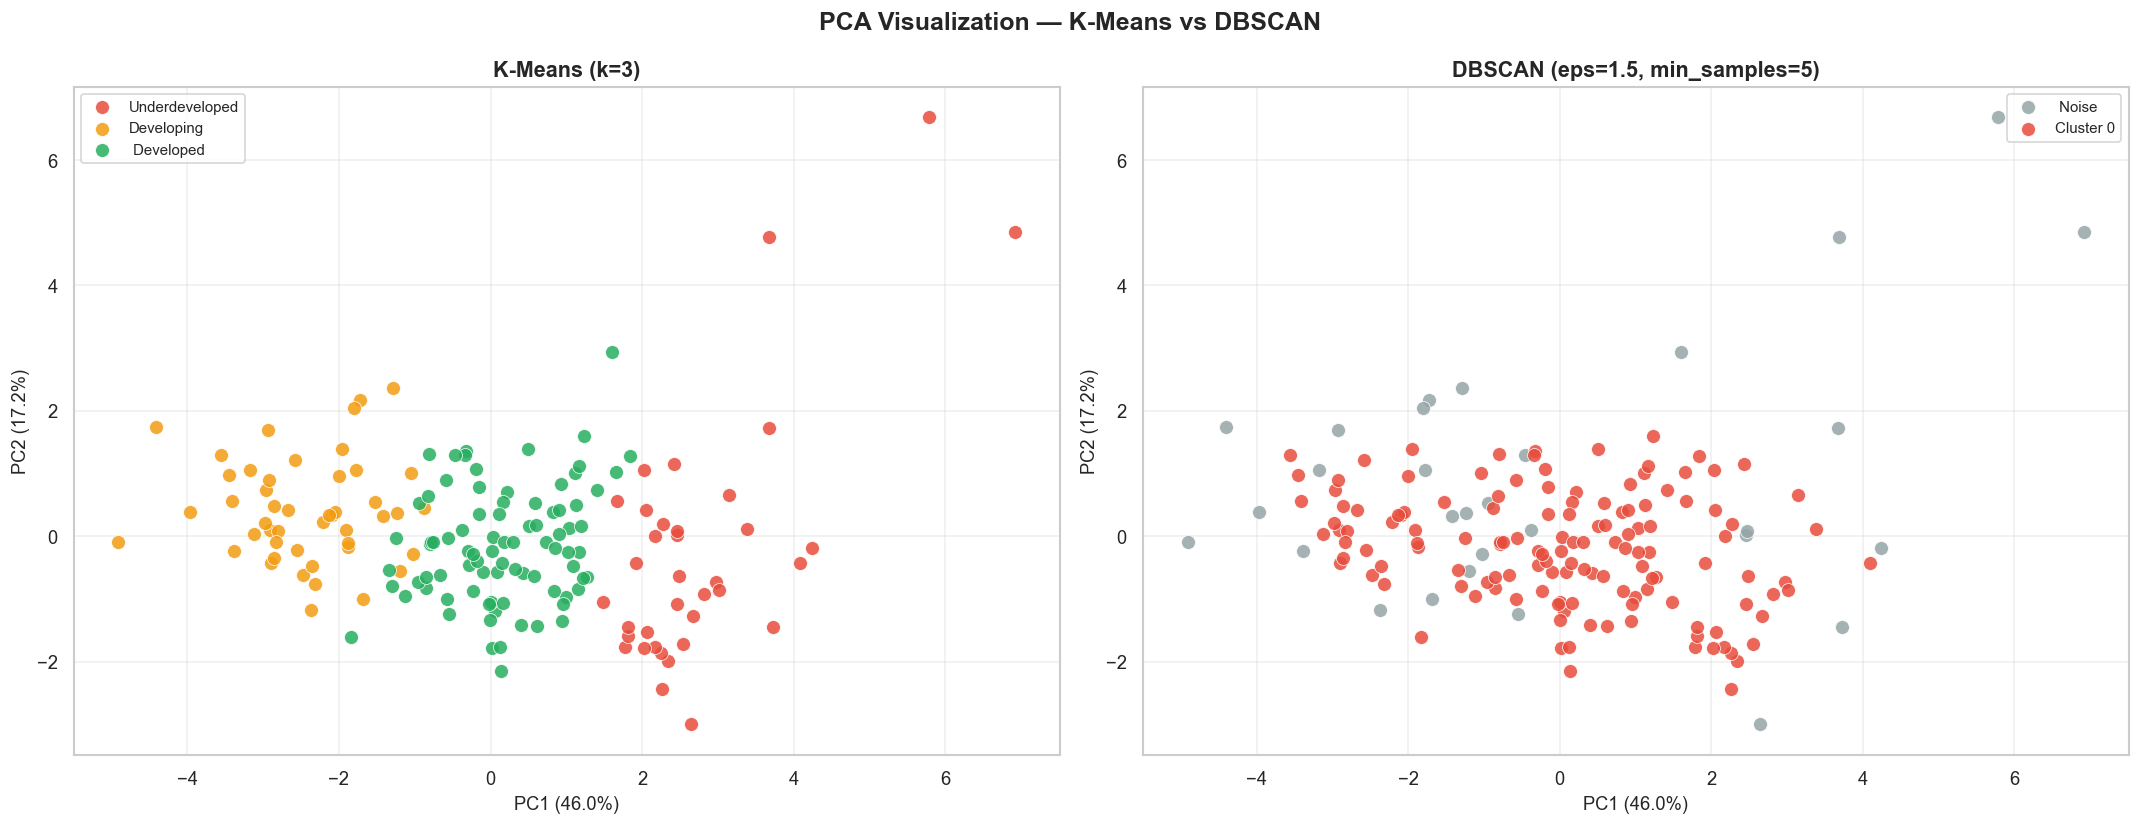

 Grey points in DBSCAN = noise/outliers not assigned to any cluster


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('PCA Visualization — K-Means vs DBSCAN', 
             fontsize=15, fontweight='bold')

# K-Means plot 
for cluster_id in range(3):
    mask = kmeans.labels_ == cluster_id
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[cluster_id],
                    label=labels_map[cluster_id],
                    s=70, alpha=0.85,
                    edgecolors='white', linewidth=0.5)
axes[0].set_title('K-Means (k=3)', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# DBSCAN plot 
dbscan_colors = {-1: '#95a5a6', 0: '#e74c3c', 1: '#27ae60', 2: '#3498db', 3: '#9b59b6'}
dbscan_label_names = {-1: ' Noise', 0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

for cluster_id in sorted(set(dbscan_labels)):
    mask = dbscan_labels == cluster_id
    label = dbscan_label_names.get(cluster_id, f'Cluster {cluster_id}')
    color = dbscan_colors.get(cluster_id, '#e67e22')
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=label,
                    s=70, alpha=0.85,
                    edgecolors='white', linewidth=0.5)
axes[1].set_title('DBSCAN (eps=1.5, min_samples=5)', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(' Grey points in DBSCAN = noise/outliers not assigned to any cluster')

In [61]:
profile_check = df.groupby('Cluster')[['gdpp', 'child_mort', 'life_expec', 'income']].mean().round(2)
print(profile_check)

             gdpp  child_mort  life_expec    income
Cluster                                            
0        42494.44        5.00       80.13  45672.22
1         1922.38       92.96       59.19   3942.40
2         6486.45       21.93       72.81  12305.60


In [62]:
cluster_names = { 0: ' Developed', 1: 'Underdeveloped',  2: ' Developing'}
df['Cluster_Name'] = df['Cluster'].map(cluster_names)

print('\n Final Cluster Summary \n')

summary = df.groupby('Cluster_Name')[['gdpp', 'child_mort', 
                                       'life_expec', 'income']].mean().round(2)
summary['Country Count'] = df['Cluster_Name'].value_counts()
print(summary.to_string())


 Final Cluster Summary 

                    gdpp  child_mort  life_expec    income  Country Count
Cluster_Name                                                             
 Developed      42494.44        5.00       80.13  45672.22             36
 Developing      6486.45       21.93       72.81  12305.60             84
Underdeveloped   1922.38       92.96       59.19   3942.40             47


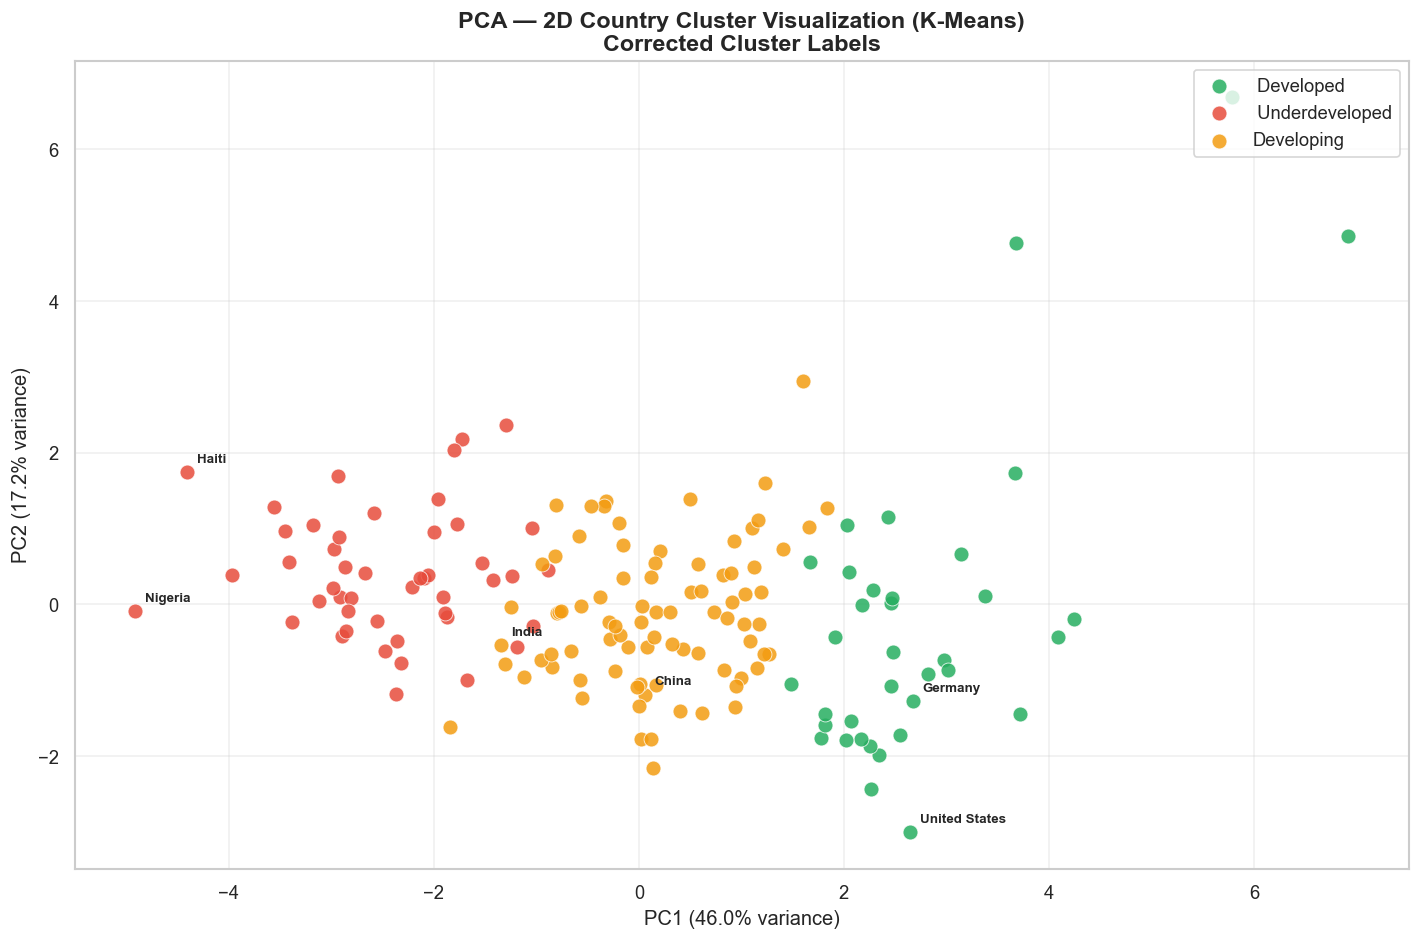

In [63]:
#  Corrected color mapping 
color_map = {0: '#27ae60', 1: '#e74c3c', 2: '#f39c12'}  
label_map  = {0: ' Developed', 1: ' Underdeveloped', 2: 'Developing'}

fig, ax = plt.subplots(figsize=(12, 8))
for cluster_id in range(3):
    mask = kmeans.labels_ == cluster_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1], c=color_map[cluster_id], label=label_map[cluster_id], s=80, alpha=0.85,edgecolors='white',linewidth=0.5
    )

notable = ['United States', 'Germany', 'India', 'China', 'Nigeria', 'Haiti']
for idx, row in df[df['country'].isin(notable)].iterrows():
    ax.annotate(row['country'],
                (X_pca[idx, 0], X_pca[idx, 1]),
                fontsize=8,
                fontweight='bold',
                xytext=(6, 6),
                textcoords='offset points')

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA — 2D Country Cluster Visualization (K-Means)\nCorrected Cluster Labels', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [64]:
X_model = X_scaled
y_model = df['Cluster'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42, stratify=y_model
)

print(f' Training samples : {X_train.shape[0]}')
print(f' Testing samples  : {X_test.shape[0]}')
print(f' Features         : {X_train.shape[1]}')

 Training samples : 133
 Testing samples  : 34
 Features         : 9


In [65]:
# ── Random Forest ──
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_preds)

print(f'\n Random Forest Results')
print(f'Accuracy : {rf_accuracy*100:.2f}%')
print(f'\n Classification Report ')
print(classification_report(y_test, rf_preds, 
      target_names=['Underdeveloped', 'Developing', 'Developed']))


 Random Forest Results
Accuracy : 100.00%

 Classification Report 
                precision    recall  f1-score   support

Underdeveloped       1.00      1.00      1.00         7
    Developing       1.00      1.00      1.00        10
     Developed       1.00      1.00      1.00        17

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



In [66]:
# XGBoost 
xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_preds)
print(f'\n XGBoost Results')
print(f'   Accuracy : {xgb_accuracy*100:.2f}%')
print(f'\n Classification Report ')
print(classification_report(y_test, xgb_preds,
      target_names=['Underdeveloped', 'Developing', 'Developed']))


 XGBoost Results
   Accuracy : 94.12%

 Classification Report 
                precision    recall  f1-score   support

Underdeveloped       1.00      0.86      0.92         7
    Developing       1.00      0.90      0.95        10
     Developed       0.89      1.00      0.94        17

      accuracy                           0.94        34
     macro avg       0.96      0.92      0.94        34
  weighted avg       0.95      0.94      0.94        34



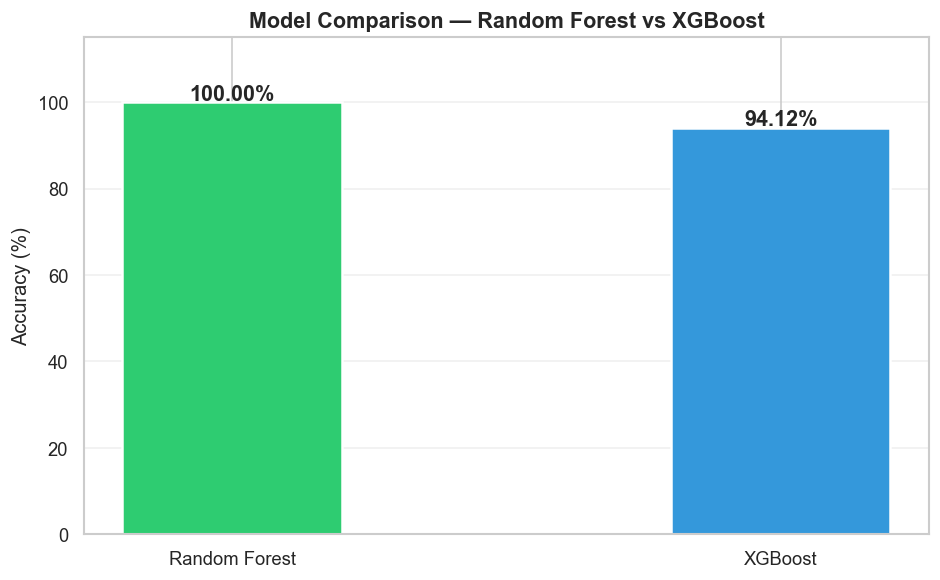


 Random Forest : 100.00%
 XGBoost       : 94.12%

 Winner : Random Forest


In [67]:
models = ['Random Forest', 'XGBoost']
accuracies = [rf_accuracy*100, xgb_accuracy*100]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(models, accuracies, color=['#2ecc71', '#3498db'],width=0.4,edgecolor='white',linewidth=1.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.5,
            f'{acc:.2f}%', 
            ha='center', fontsize=13, fontweight='bold')

ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison — Random Forest vs XGBoost',fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n Random Forest : {rf_accuracy*100:.2f}%')
print(f' XGBoost       : {xgb_accuracy*100:.2f}%')
winner = 'Random Forest' if rf_accuracy > xgb_accuracy else 'XGBoost'
print(f'\n Winner : {winner}')

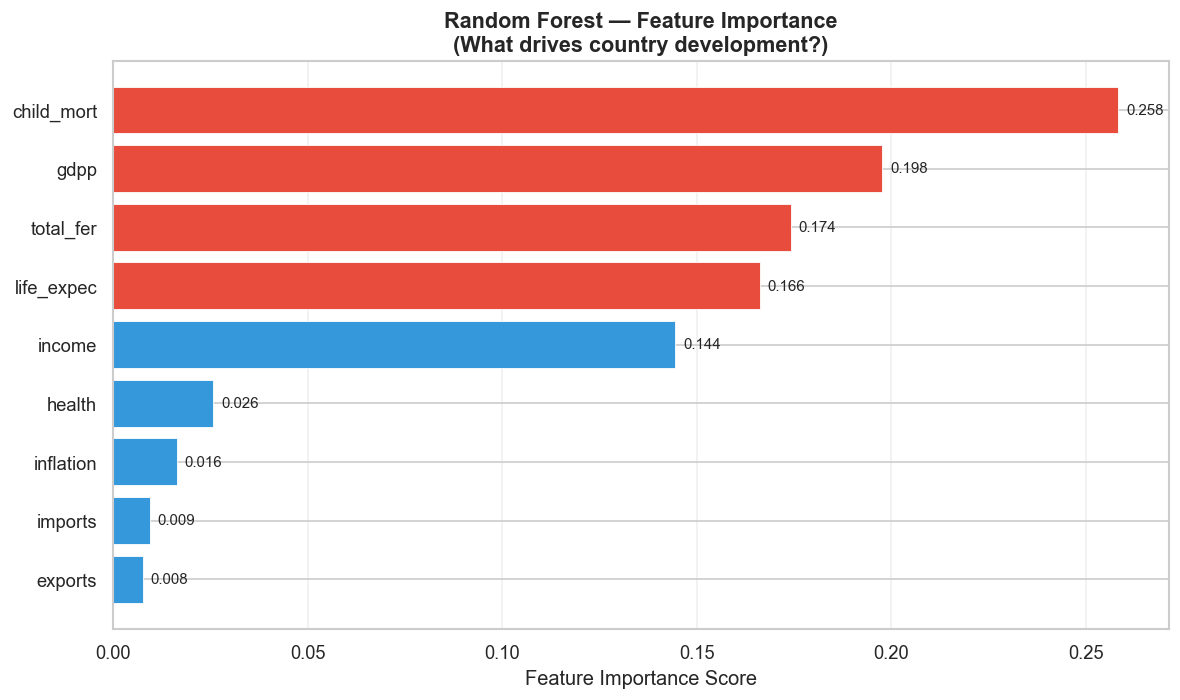


 Top 3 Most Important Features 
 child_mort      : 0.2584
 gdpp            : 0.1977
 total_fer       : 0.1741


In [68]:
# Feature Importance 
importances = rf_model.feature_importances_
feat_names = list(X.columns)

feat_df = pd.DataFrame({
    'Feature': feat_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c' if x > 0.15 else '#3498db' for x in feat_df['Importance']]
bars = ax.barh(feat_df['Feature'], feat_df['Importance'], 
                color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, feat_df['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Random Forest — Feature Importance\n(What drives country development?)', 
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n Top 3 Most Important Features ')
top3 = feat_df.nlargest(3, 'Importance')
for _, row in top3.iterrows():
    print(f' {row["Feature"]:<15} : {row["Importance"]:.4f}')